# Lib

In [5]:
# IMPORT ALL LIB 
import subprocess
import numpy as np  
import matplotlib.pyplot as plt 
import os
import json
import time


#%pip install pyvisa
#%pip install pyvisa-py
#import pyvisa  
#print("pyvisa==",pyvisa.__version__)


# EMI reciver
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# Utils

In [2]:
def finNbBits(raw):
    #nbBits = 
    for i in range(16,0,-1):
        y = raw/2**i
        if np.abs(y-y.round()).max()==0:
            return 16-i
    # I test this function i get 9, so nb = 9 as datasheet 

In [3]:
def tran_sampling(N = 10, nbpoints = 10000):
    arr = np.zeros((N, nbpoints), dtype='>i2')
    for i in range(N):
        raw = get_data_raw()
        arr[i] = raw
    arr = arr.flatten()
    return arr

## EMI RECIVER 

### FFT

In [4]:
def voltage_to_dBuV_spectrum(arr, Ts):
    """
    Compute the single-sided voltage spectrum of arr (in volts),
    and convert to dBµV (decibels relative to 1 µV).
    
    Returns:
        freqs: numpy array of frequency bins (Hz)
        spectrum_dBuV: numpy array of magnitudes in dBµV
    """
    N = len(arr)
    # FFT
    Y = rfft(arr)
    # Frequency bins
    freqs = rfftfreq(N, Ts)
    
    # Compute amplitude spectrum (peak)
    # Norm: divide by N so that the amplitude reflects actual signal amplitude
    # Because rfft gives only half spectrum, multiply non-DC components by 2
    # e.g. see many DSP references
    
    # Magnitude (absolute)
    mag = np.abs(Y) / N
    # multiply by 2 (for single-sided), except DC component at index 0
    mag[1:] = mag[1:] * 2

    # Convert volts → microvolts
    mag_uV = mag * 1e6  # now in µV

    # avoid log of zero
    #eps = 1e-20
    spectrum_dBuV = 20 * np.log10(mag_uV )
    
    return freqs, spectrum_dBuV

### Gaussian 9 kHz RBW instead of boxcar

In [5]:

# ---------- Helpers ----------

def _next_pow2(n):
    # next power of two >= n
    return 1 << (int(n - 1).bit_length())

def _choose_nfft(fs, rbw_hz, oversample=5, max_nfft=1 << 18):
    """
    Pick NFFT so that Δf = fs/NFFT <= RBW/oversample, limited to max_nfft.
    """
    target_df = rbw_hz / float(oversample)
    nfft = int(np.ceil(fs / target_df))
    nfft = _next_pow2(max(1024, nfft))
    return min(nfft, max_nfft)

def _one_sided_psd(frame, fs, window):
    """
    Periodogram with window power normalization, one-sided doubling.
    PSD units: V^2/Hz. Shape: (N/2+1,)
    """
    N = len(frame)
    U = np.mean(window**2)  # window power
    X = rfft(frame * window)
    psd = (np.abs(X)**2) / (fs * N * U)  # two-sided to start
    # One-sided doubling (except DC and Nyquist for even N)
    if N % 2 == 0:
        psd[1:-1] *= 2.0
    else:
        psd[1:] *= 2.0
    return psd
def _quasi_peak(envelope, dt, tau_c, tau_d, return_mode="max"):
    """
    Quasi-peak detector on a non-negative envelope (e.g., Vrms in RBW per frame).
    Attack (charge) with tau_c, decay (discharge) with tau_d.
    Return either the max detector output over time or the final value.
    """
    y = 0.0
    out = np.empty_like(envelope)
    a_c = np.exp(-dt / tau_c)
    a_d = np.exp(-dt / tau_d)
    for i, x in enumerate(envelope):
        if x >= y:
            y = a_c * y + (1 - a_c) * x
        else:
            y = a_d * y + (1 - a_d) * x
        out[i] = y
    return out.max() if return_mode == "max" else out[-1]

def _gaussian_rbw_kernel(df, rbw_hz, span_sigmas=5):
    """
    Build |H(f)|^2 kernel approximating CISPR quasi-Gaussian RBW.

    We choose a Gaussian AMPLITUDE response H(f) with –6 dB amplitude at ±RBW/2.
    For Gaussian amplitude: H(f) = exp(-(f^2)/(2σ^2)).
      –6 dB amplitude point: |H(f6)| = 10^(-6/20) ≈ 0.501187.
      => f6 = σ * sqrt(2 ln(1/0.501187)) ≈ 1.176 σ  ⇒ σ ≈ (RBW/2)/1.176.
    We convolve PSD with |H|^2, then multiply by Δf to approximate ∫ PSD·|H|^2 df.
    """
    f6 = rbw_hz / 2.0
    sigma = f6 / 1.176  # ≈ RBW / 2.352

    # Discretize kernel over ±span_sigmas·σ
    half_span_hz = span_sigmas * sigma
    half_bins = int(np.ceil(half_span_hz / df))
    offs = (np.arange(-half_bins, half_bins + 1) * df)
    H_amp = np.exp(-0.5 * (offs / sigma) ** 2)   # amplitude response
    kernel_power = H_amp ** 2                    # |H|^2 for power integration
    return kernel_power

# ---------- Main function ----------
def emi_detectors_rbw2(arr, Ts, rbw_hz=9e3, window_name='hann',
                      nfft=None, overlap=0.75,
                      qp_band='B', qp_return='max',
                      rbw_shape='gaussian', span_sigmas=5):
    """
    Compute Peak / Average / Quasi-Peak in dBµV for RBW integration.

    Parameters
    ----------
    arr : 1D np.ndarray
        Time-domain signal in Volts.
    Ts : float
        Sampling period in seconds.
    rbw_hz : float
        Resolution bandwidth (Hz). Default 9 kHz.
    window_name : {'hann','rect'}
        STFT analysis window (leakage control; not the IF filter).
    nfft : int or None
        FFT size per frame. If None, chosen automatically vs RBW.
    overlap : float in [0,1)
        Frame overlap fraction.
    qp_band : {'A','B','C','D'}
        CISPR band for QP time constants:
        - A: 9–150 kHz → RBW 200 Hz, τc=45 ms, τd=500 ms
        - B: 150 kHz–30 MHz → RBW 9 kHz, τc=1 ms, τd=160 ms (default)
        - C/D: ≥30 MHz → RBW 120 kHz, τc=1 ms, τd=550 ms
    qp_return : {'max','final'}
        Return max or final quasi-peak output along time.
    rbw_shape : {'gaussian','rect'}
        RBW integration kernel in frequency. 'gaussian' approximates CISPR IF.
    span_sigmas : int
        Width of Gaussian kernel in ±σ units (only used for 'gaussian').

    Returns
    -------
    freqs : 1D array (Hz)
    dBuV_peak : 1D array
    dBuV_avg  : 1D array
    dBuV_qp   : 1D array
    """

    fs = 1.0 / Ts
    x = np.asarray(arr, dtype=float)
    Nsig = len(x)

    # Analysis window (for PSD leakage control)
    if window_name == 'hann':
        win_fn = np.hanning
    elif window_name == 'rect':
        win_fn = np.ones
    else:
        raise ValueError("window_name must be 'hann' or 'rect'")

    # Pick NFFT if not provided
    if nfft is None:
        nfft = _choose_nfft(fs, rbw_hz, oversample=5)
    nfft = min(nfft, Nsig) if Nsig < nfft else nfft

    hop = max(1, int(nfft * (1.0 - overlap)))
    window = win_fn(nfft)

    # Frame indices
    starts = np.arange(0, Nsig - nfft + 1, hop, dtype=int)
    if len(starts) == 0:
        # zero-pad one frame
        pad = np.zeros(nfft, dtype=float)
        pad[:Nsig] = x
        frames = pad[None, :]
        starts = np.array([0])
    else:
        frames = np.lib.stride_tricks.as_strided(
            x, shape=(len(starts), nfft),
            strides=(x.strides[0]*hop, x.strides[0])
        ).copy()

    # PSD per frame (one-sided)
    psd_list = []
    for fr in frames:
        psd_list.append(_one_sided_psd(fr, fs, window))
    psd = np.vstack(psd_list)    # shape: (T, F)
    freqs = rfftfreq(nfft, Ts)
    df = fs / nfft

    # ----- RBW integration via kernel in frequency -----
    if rbw_shape == 'gaussian':
        ker = _gaussian_rbw_kernel(df, rbw_hz, span_sigmas=span_sigmas)
    elif rbw_shape == 'rect':
        bins_in_rbw = max(1, int(round(rbw_hz / df)))
        ker = np.ones(bins_in_rbw, dtype=float)
    else:
        raise ValueError("rbw_shape must be 'gaussian' or 'rect'")

    from numpy import convolve
    P_rbw = np.empty_like(psd)
    for t in range(psd.shape[0]):
        if rbw_shape == 'rect':
            psd_sum = np.convolve(psd[t], ker, mode='same')
            P_rbw[t] = psd_sum * df               # rectangular: sum * Δf
        else:
            # Gaussian: integrate PSD * |H|^2 over frequency
            psd_w = np.convolve(psd[t], ker, mode='same')
            P_rbw[t] = psd_w * df                 # ∑ PSD·|H|^2 · Δf ≈ ∫ PSD·|H|^2 df

    # Voltage RMS per time & frequency
    Vrms = np.sqrt(np.maximum(P_rbw, 0.0))  # shape (T, F)

    # Detectors along time
    Vrms_peak = Vrms.max(axis=0)    # Peak
    Vrms_avg  = Vrms.mean(axis=0)   # Average (linear)

    # Quasi-Peak constants per CISPR band
    if qp_band.upper() == 'A':
        tau_c, tau_d = 45e-3, 500e-3
    elif qp_band.upper() == 'B':
        tau_c, tau_d = 1e-3, 160e-3
    elif qp_band.upper() in ('C', 'D'):
        tau_c, tau_d = 1e-3, 550e-3
    else:
        raise ValueError("qp_band must be one of {'A','B','C','D'}")

    dt = hop / fs  # detector time step equals frame hop duration
    Vrms_qp = np.empty(Vrms.shape[1], dtype=float)
    for f_idx in range(Vrms.shape[1]):
        Vrms_qp[f_idx] = _quasi_peak(Vrms[:, f_idx], dt, tau_c, tau_d, return_mode=qp_return)

    # Convert to dBµV
    eps = 1e-15  # numerical floor to prevent log(0)
    dBuV_peak = 20.0 * np.log10(np.maximum(Vrms_peak, eps) * 1e6)
    dBuV_avg  = 20.0 * np.log10(np.maximum(Vrms_avg,  eps) * 1e6)
    dBuV_qp   = 20.0 * np.log10(np.maximum(Vrms_qp,   eps) * 1e6)

    return freqs, dBuV_peak, dBuV_avg, dBuV_qp

In [6]:
### Remove 10 KHZ oscillation

In [7]:
# max step = 5khz see 
# RBW of 9 kHz and a maximum step size of 5 kHz 
# https://www.ti.com/lit/eb/slyy208/slyy208.pdf
def remove_oscillation_10kHz(freqs , dBuV_qp, step = 2.5e3,fstart=150e3, fend=30e6, distance=2):
    """
    Removes small oscillations (~10 kHz) from quasi-peak spectrum data
    by extracting the peak envelope and interpolating it with a smooth curve.

    Parameters
    ----------
    freqs : ndarray
        Frequency array in Hz corresponding to the measurements.
    dBuV_qp : ndarray
        Quasi-peak detector amplitude values in dBµV.
    step : float, optional
        Frequency step in Hz for interpolation (default = 2.5 kHz).

    Returns
    -------
    newFreq : ndarray
        New frequency grid from 150 kHz to 30 MHz with given step.
    dbpeakinter : ndarray
        Interpolated envelope values (dBµV) corresponding to newFreq.
    """

    # Detect peaks with a tighter distance (actual peaks used in envelope construction)
    peaks, _ = find_peaks(dBuV_qp, distance=distance)

    # Extract amplitude values of detected peaks
    dbpeak = dBuV_qp[peaks]

    # Extract frequency positions of detected peaks
    freqpeak = freqs[peaks]

    # Define new frequency grid from 150 kHz to 30 MHz
    newFreq = np.arange(fstart, fend, step)

    # Interpolate envelope over the new frequency grid using cubic interpolation
    env_fun = interp1d(
        freqpeak, dbpeak, 
        kind='cubic', 
        bounds_error=False, 
        fill_value="extrapolate"
    )

    # Evaluate the interpolated envelope
    dbpeakinter = env_fun(newFreq)

    return newFreq, dbpeakinter


In [8]:
def EMI_emulator(arr, Ts, rbw_hz=9e3, window_name='hann',
                      nfft=None, overlap=0.75,
                      qp_band='B', qp_return='max',
                      rbw_shape='gaussian', span_sigmas=5, 
                 step = 2.5e3,fstart=150e3, fend=30e6, distance=2,
                detectors= ["peak", "avg","qpeak"]):
    freqs, dBuV_peak, dBuV_avg, dBuV_qp= emi_detectors_rbw2(arr=arr, Ts=Ts, rbw_hz=rbw_hz, window_name=window_name,
                          nfft=nfft, overlap=overlap,
                          qp_band=qp_band, qp_return=qp_return,
                          rbw_shape=rbw_shape, span_sigmas=span_sigmas)
    etherArr={"peak": dBuV_peak, "avg":dBuV_avg, "qpeak":dBuV_qp}
    
    dic_res = {}
    for det in detectors: 
        val = etherArr[det]
        newFreq,val2  = remove_oscillation_10kHz(freqs , val, step = step,
                                             fstart=fstart, fend=fend, distance=distance)
        dic_res[det]= val2
        
    dic_res["freq"]= newFreq
    return dic_res

### EMI processing

In [6]:
EMI_emulator

NameError: name 'EMI_emulator' is not defined

In [7]:
arr = np.load("EMI_2026-02-03_18-00-38-109/CH4_raw.npy")
arr.shape

(50, 10000)

In [8]:
arr

array([[-3072, -3200, -3584, ..., -2816, -2304, -2560],
       [-2048, -2432, -2816, ..., -2560, -1920, -2048],
       [-3200, -3200, -2944, ..., -2816, -3456, -3072],
       ...,
       [-2944, -2688, -2688, ..., -1664, -2176, -2176],
       [-3072, -1280, -2560, ..., -1536, -1792, -3200],
       [-3456, -2944, -3072, ..., -2176, -2048, -2688]],
      shape=(50, 10000), dtype=int16)

In [9]:
arr.flatten() 

array([-3072, -3200, -3584, ..., -2176, -2048, -2688],
      shape=(500000,), dtype=int16)

In [10]:
yraw=arr.flatten() 

In [11]:
with open("EMI_2026-02-03_18-00-38-109/CH4_seeting.txt") as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)
dic

{'BANDWIDTH': 'FULL\n',
 'COUPLING': 'DC\n',
 'IMPEDANCE': 'FIFTY\n',
 'INVERT': '0\n',
 'OFFSET': '0.0E0\n',
 'POSITION': '-4.0E-2\n',
 'PROBe': '1.0E1\n',
 'SCALE': '1.0E1\n',
 'channel': 'CH4',
 'x_increment': '2.0E-8\n',
 'x_origin': '-1.002E-4\n',
 'y_increment': '1.5625E-3\n',
 'y_offset': '-2.56E2\n',
 'y_origin': '0.0E0\n'}

In [12]:
def raw_to_volte(raw, dic):
    y_increment =  float(dic["y_increment"])
    y_origin =  float(dic["y_origin"])
    y_offset =  float(dic["y_offset"])
    voltage = (raw - y_offset) * y_increment + y_origin
    return voltage 



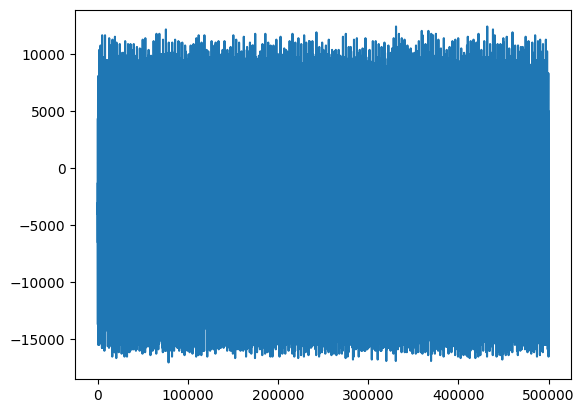

In [13]:
plt.plot(yraw)

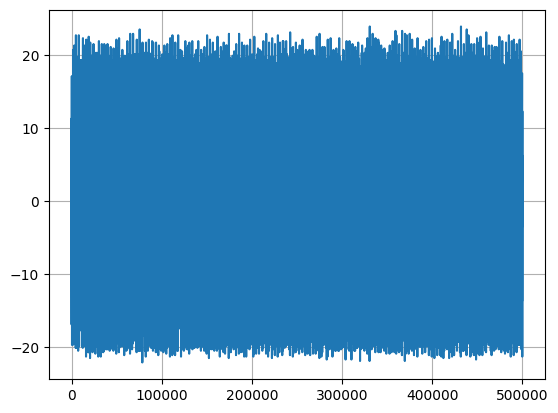

In [14]:
y=raw_to_volte(yraw, dic)
y=y-y.mean()

plt.plot(y)
plt.grid()

In [15]:
rms=np.sqrt((y**2).mean())
rms

np.float64(2.1168495266260567)

In [16]:
Ts=float(dic['x_increment'])
1e-6/Ts,"Mhz"

(50.0, 'Mhz')

In [17]:
%%time 
dic_res = EMI_emulator(arr=y, Ts=Ts, rbw_hz=9e3,  
                 step = 2.5e3,fstart=150e3, fend=30e6, 
                detectors= [ "avg","qpeak"])

CPU times: total: 0 ns
Wall time: 12.9 μs


NameError: name 'EMI_emulator' is not defined

In [21]:
%%time 
dic_res = EMI_emulator(arr=y, Ts=Ts, rbw_hz=9e3,  
                 step = 2.5e3,fstart=100e3, fend=30e6, 
                detectors= [ "avg","qpeak"])

CPU times: total: 1.02 s
Wall time: 1.82 s


In [22]:
freqs = dic_res['freq']
avg= dic_res['avg']
qpeak = dic_res['qpeak']

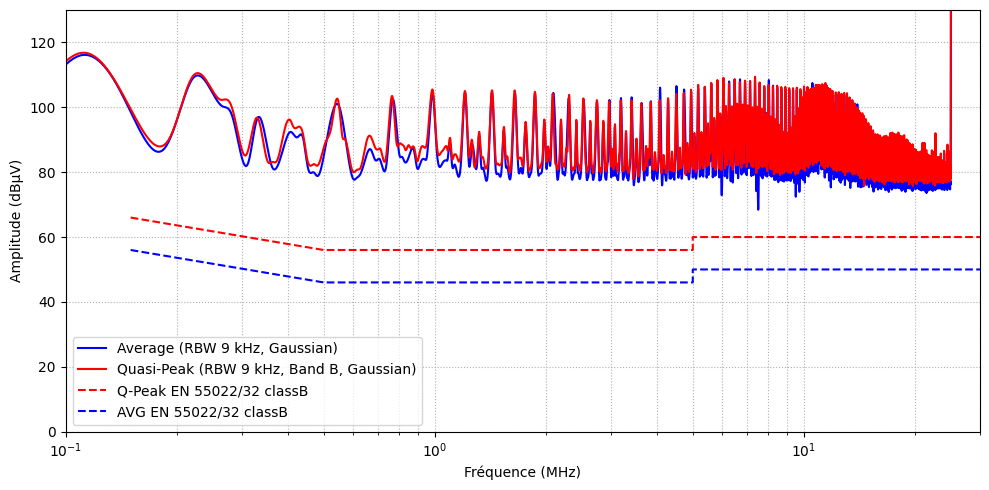

In [23]:
plt.figure(figsize=(10,5))


plt.semilogx(freqs*1e-6, avg,  label='Average (RBW 9 kHz, Gaussian)',c="b")
plt.semilogx(freqs*1e-6, qpeak,   label='Quasi-Peak (RBW 9 kHz, Band B, Gaussian)',c="r")

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")
plt.ylim([0,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Fréquence (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amplitude (dBµV)')
plt.legend()
plt.tight_layout()
plt.show()

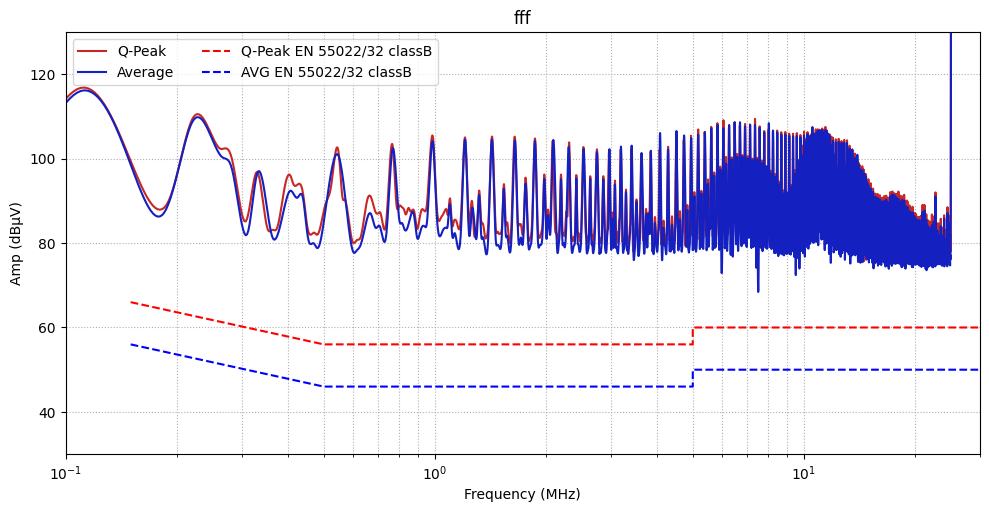

In [24]:
title="fff"
plt.figure(figsize=(10,5))

plt.semilogx(freqs*1e-6, qpeak, label='Q-Peak', color='#C62828')  # slightly lighter red
plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0')  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")
plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [34]:
def EMI_emulatorSIMPLE(arr, Ts, rbw_hz=9e3, window_name='hann',
                      nfft=None, overlap=0.75,
                      qp_band='B', qp_return='max',
                      rbw_shape='gaussian', span_sigmas=5, 
                 step = 2.5e3,fstart=150e3, fend=30e6, distance=2,
                detectors= ["peak", "avg","qpeak"]):
    freqs, dBuV_peak, dBuV_avg, dBuV_qp= emi_detectors_rbw2(arr=arr, Ts=Ts, rbw_hz=rbw_hz, window_name=window_name,
                          nfft=nfft, overlap=overlap,
                          qp_band=qp_band, qp_return=qp_return,
                          rbw_shape=rbw_shape, span_sigmas=span_sigmas)
    etherArr={"freq":freqs, 
              "peak": dBuV_peak, "avg":dBuV_avg, "qpeak":dBuV_qp}
    return etherArr

In [35]:
%%time 
dic_res = EMI_emulatorSIMPLE(arr=y, Ts=Ts, rbw_hz=9e3,  
                 step = 2.5e3,fstart=150e3, fend=30e6, 
                detectors= [ "avg","qpeak"])

freqs = dic_res['freq']
avg= dic_res['avg']
qpeak = dic_res['qpeak']

CPU times: total: 359 ms
Wall time: 987 ms


In [36]:
dic_res 

{'freq': array([0.00000000e+00, 1.52587891e+03, 3.05175781e+03, ...,
        2.49969482e+07, 2.49984741e+07, 2.50000000e+07], shape=(16385,)),
 'peak': array([102.26616147, 102.52533582, 101.64111034, ...,  87.69517439,
         87.72277992,  87.42445627], shape=(16385,)),
 'avg': array([92.8219736 , 93.46263771, 93.04581901, ..., 85.90912948,
        86.38013404, 85.75281491], shape=(16385,)),
 'qpeak': array([97.13833897, 97.31048459, 96.38173254, ..., 86.97335408,
        87.15631482, 86.80106582], shape=(16385,))}

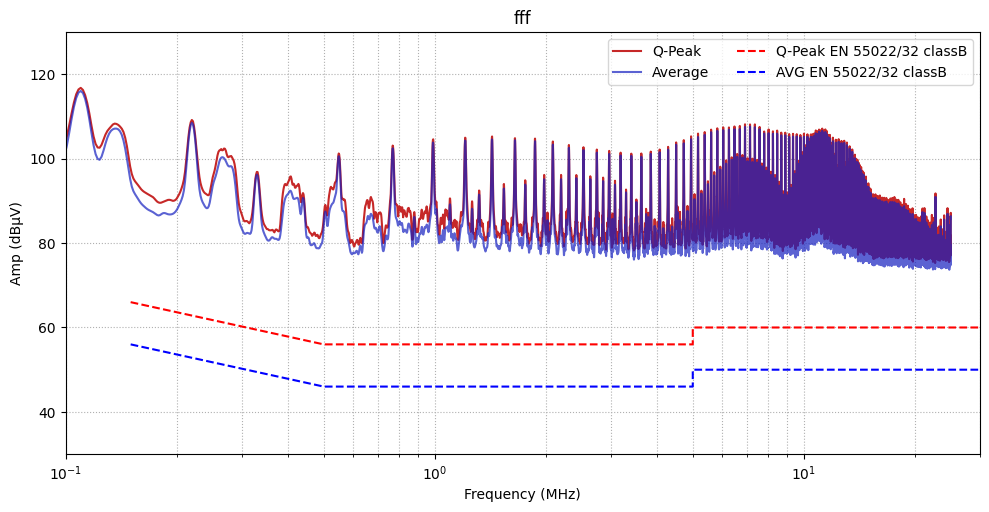

In [38]:
title="fff"
plt.figure(figsize=(10,5))

plt.semilogx(freqs*1e-6, qpeak, label='Q-Peak', color='#C62828')  # slightly lighter red
plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")
plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [27]:
help(voltage_to_dBuV_spectrum)

Help on function voltage_to_dBuV_spectrum in module __main__:

voltage_to_dBuV_spectrum(arr, Ts)
    Compute the single-sided voltage spectrum of arr (in volts),
    and convert to dBµV (decibels relative to 1 µV).

    Returns:
        freqs: numpy array of frequency bins (Hz)
        spectrum_dBuV: numpy array of magnitudes in dBµV



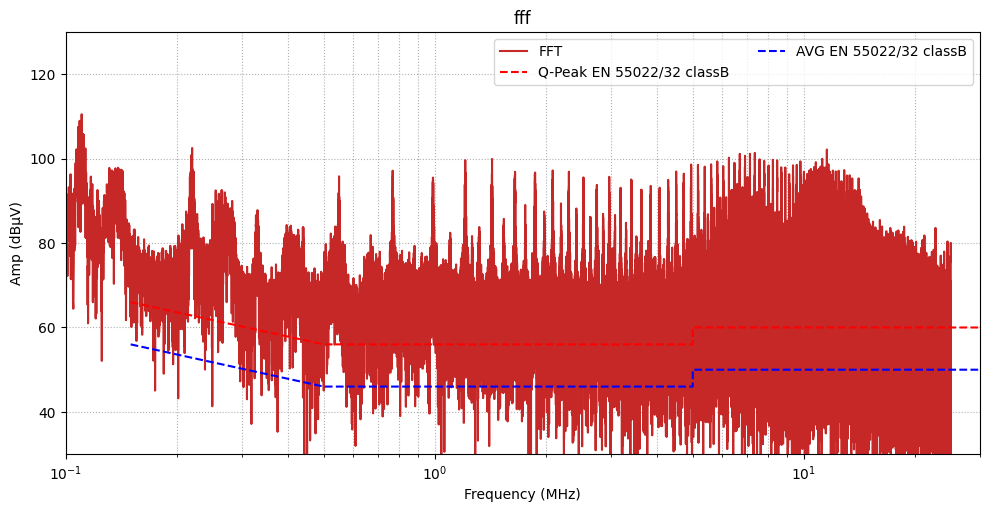

In [29]:
freqs,spectrum_dBuV= voltage_to_dBuV_spectrum(y, Ts)

title="fff"
plt.figure(figsize=(10,5))

plt.semilogx(freqs*1e-6, spectrum_dBuV, label='FFT', color='#C62828')  # slightly lighter red
#plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0')  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")
plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [44]:
import numpy as np
from scipy.signal import butter, lfilter

def fast_emi_receiver_SAFE(
    x, fs,
    fstart=150e3, fend=30e6, step=20e3,   # coarser step first!
    rbw=9e3,
    dwell_time=2e-3                      # shorter dwell
):
    Ns = int(dwell_time * fs)
    x = x[:Ns]                            # 🔥 ABSOLUTELY REQUIRED
    t = np.arange(Ns) / fs

    b, a = butter(3, rbw / (fs / 2))

    freqs = np.arange(fstart, fend, step)
    peak = np.zeros(len(freqs))

    for i, fc in enumerate(freqs):
        lo = np.exp(-1j * 2*np.pi * fc * t)
        bb = np.real(x * lo)
        y = lfilter(b, a, bb)
        peak[i] = np.max(np.abs(y))

    peak = 20*np.log10(np.maximum(peak, 1e-15)*1e6)
    return freqs, peak


In [47]:
freqs, peak = fast_emi_receiver_SAFE(
    y, fs=1/Ts,
    step=5e3,
    dwell_time=1e-3
)


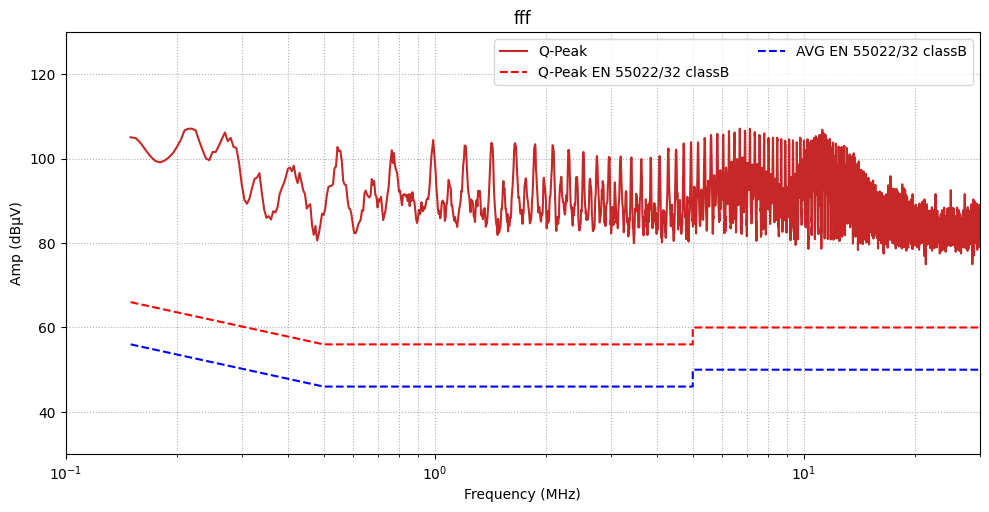

In [48]:
title="fff"
plt.figure(figsize=(10,5))

plt.semilogx(freqs*1e-6, peak, label='Q-Peak', color='#C62828')  # slightly lighter red
#plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")
plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [20]:
import numpy as np
import scipy.signal
import scipy.fft
from numba import jit
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. High-Performance Detector Kernels (JIT Compiled)
# ---------------------------------------------------------
@jit(nopython=True)
def quasi_peak_filter(magnitude_signal, dt, tau_charge, tau_discharge):
    """
    Simulates the CISPR Quasi-Peak detector circuit (RC charge/discharge).
    
    magnitude_signal : 1D array of voltage envelope
    dt               : Time step between samples (1/Fs_effective)
    tau_charge       : Charge time constant (s)
    tau_discharge    : Discharge time constant (s)
    """
    n_samples = len(magnitude_signal)
    output = np.zeros(n_samples, dtype=np.float64)
    
    # Pre-calculate decay and charge factors to save operations
    # Standard digital IIR approximation for RC circuit
    alpha_charge = 1.0 - np.exp(-dt / tau_charge)
    alpha_discharge = 1.0 - np.exp(-dt / tau_discharge)
    
    current_val = 0.0
    
    for i in range(n_samples):
        in_val = magnitude_signal[i]
        
        if in_val > current_val:
            # Charging phase
            current_val += alpha_charge * (in_val - current_val)
        else:
            # Discharging phase
            current_val -= alpha_discharge * current_val
            
        output[i] = current_val
        
    return np.max(output) # QP returns the maximum level reached by the detector

@jit(nopython=True, parallel=True)
def run_detectors_parallel(spectrogram_mag, dt, tau_c, tau_d):
    """
    Runs detectors on the full spectrogram matrix.
    Parallelized over frequency bins.
    """
    n_time, n_freq = spectrogram_mag.shape
    
    res_peak = np.zeros(n_freq)
    res_avg = np.zeros(n_freq)
    res_qp = np.zeros(n_freq)
    
    for f in range(n_freq):
        # Extract the time-series for this specific frequency bin
        time_trace = spectrogram_mag[:, f]
        
        # 1. PEAK Detector
        res_peak[f] = np.max(time_trace)
        
        # 2. AVERAGE Detector
        res_avg[f] = np.mean(time_trace)
        
        # 3. QUASI-PEAK Detector
        res_qp[f] = quasi_peak_filter(time_trace, dt, tau_c, tau_d)
        
    return res_peak, res_avg, res_qp

# ---------------------------------------------------------
# 2. Main Logic: Signal -> Window -> STFT -> Detectors
# ---------------------------------------------------------
def emi_receiver_fft(signal, fs, rbw=9000, start_freq=0, band='B'):
    """
    Emulates an EMI Receiver using FFT Scan.
    
    Parameters:
    -----------
    signal : np.array
        Time domain signal (Volts)
    fs : float
        Sampling Rate (Hz)
    rbw : float
        Resolution Bandwidth (Hz) - usually 9kHz for Band B
    band : str
        CISPR Band ('A', 'B', 'C', 'D') for QP constants
        
    Returns:
    --------
    freqs, peak_dBuV, avg_dBuV, qp_dBuV
    """
    
    # --- A. Setup Constants based on Band ---
    if band == 'A': # 9k - 150k
        tau_c, tau_d = 45e-3, 500e-3
    elif band == 'B': # 150k - 30M
        tau_c, tau_d = 1e-3, 160e-3
    else: # C/D > 30M
        tau_c, tau_d = 1e-3, 550e-3

    # --- B. Design the "RBW" Window ---
    # We use a Gaussian window to mimic the CISPR IF filter.
    # We must calculate the window standard deviation (sigma) in time 
    # that corresponds to the requested RBW (6dB bandwidth).
    # Math: RBW_6dB = 2 * sqrt(2 * ln(2)) * sigma_f
    #       sigma_t = 1 / (2 * pi * sigma_f)
    
    sigma_f = rbw / (2 * np.sqrt(2 * np.log(2)))
    sigma_t = 1.0 / (2 * np.pi * sigma_f)
    
    # Window length: usually +/- 3 or 4 sigmas is enough to capture the bell curve
    # Ensure window length is odd
    win_len_sec = 6 * sigma_t 
    nperseg = int(win_len_sec * fs)
    if nperseg % 2 == 0: nperseg += 1
    
    # Generate Window
    # Scipy's gaussian takes std in samples
    sigma_samples = sigma_t * fs
    window = scipy.signal.windows.gaussian(nperseg, std=sigma_samples)
    
    # --- C. Normalization (CRITICAL) ---
    # An EMI receiver must display correct Amplitude for a Sine Wave.
    # Coherent Gain Correction: Amplitude / sum(window) * 2 (for one-sided FFT)
    # However, for STFT implementation, we normalize the window energy.
    # The standard way: Normalize window so sum(window) = 1, then multiply FFT by 2.
    window = window / np.sum(window) 
    
    # --- D. Overlap Configuration ---
    # To emulate a continuous time detector, we need high overlap.
    # Step size should be small enough to capture pulse evolution.
    overlap_ratio = 0.90 
    noverlap = int(nperseg * overlap_ratio)
    step_size = nperseg - noverlap
    
    # Effective Sample Rate of the Detector
    fs_detector = fs / step_size
    dt_detector = 1.0 / fs_detector
    
    print(f"DEBUG: RBW={rbw}Hz | Window Size={nperseg} | Overlap={overlap_ratio*100}%")
    print(f"DEBUG: Detector Sampling Time={dt_detector*1e3:.4f}ms (Should be < Tau_charge)")

    if dt_detector > tau_c:
        print("WARNING: FFT Overlap is too low for this Quasi-Peak Band! Increase overlap or Fs.")

    # --- E. Perform STFT ---
    # returns: f (freqs), t (times), Zxx (Complex)
    f_axis, t_axis, Zxx = scipy.signal.stft(
        signal, fs, 
        window=window, 
        nperseg=nperseg, 
        noverlap=noverlap, 
        nfft=nperseg,     # Use window size as FFT size (or next power of 2 for speed)
        boundary='zeros',
        padded=True
    )

    # Convert to One-Sided Magnitude (Voltage)
    # Factor of 2 accounts for negative frequencies lost in rfft (except DC)
    # Note: Scipy STFT with normalized window usually handles scaling, 
    # but we manually forced sum(win)=1.
    # For a sine wave of amp 1V: 
    # STFT output magnitude with sum(win)=1 is 0.5V (energy split +/- freq).
    # So we multiply by 2.0.
    
    mag_spectrogram = np.abs(Zxx) * 2.0
    
    # Transpose to shape (Time, Freq) for iterating
    mag_spectrogram_T = mag_spectrogram.T 

    # --- F. Run Detectors (Fast Numba) ---
    peak_v, avg_v, qp_v = run_detectors_parallel(mag_spectrogram_T, dt_detector, tau_c, tau_d)

    # --- G. Convert to dBµV ---
    # dBµV = 20 * log10(Voltage / 1uV)
    def to_dbuv(v_array):
        # Add epsilon to avoid log(0)
        return 20 * np.log10(np.maximum(v_array, 1e-12) * 1e6)

    return f_axis, to_dbuv(peak_v), to_dbuv(avg_v), to_dbuv(qp_v)


# ---------------------------------------------------------
# 3. Test & Visualization
# ---------------------------------------------------------
if False : #__name__ == "__main__":
    # Settings
    Fs = 100e6      # 100 MS/s
    Duration = 0.05 # 50ms capture
    t = np.arange(int(Fs * Duration)) / Fs
    
    # Generate Synthetic Signal:
    # 1. 150 kHz Sine wave (Continuous) -> Should match Peak/QP/Avg
    sig1 = 100e-6 * np.sin(2 * np.pi * 150e3 * t) # 100uV = 40 dBuV
    
    # 2. 500 kHz Pulse (Burst) -> Peak > QP > Avg
    # Burst every 10ms, duration 10us
    sig2 = 500e-6 * np.sin(2 * np.pi * 500e3 * t) # 500uV = 54 dBuV
    burst_mask = (t % 0.010) < 10e-6 
    sig2 = sig2 * burst_mask
    
    signal = sig1 + sig2
    
    print("Processing Signal...")
    freqs, peak, avg, qp = emi_receiver_fft(signal, Fs, rbw=9000, band='B')
    
    # Plotting
    mask = (freqs >= 100e3) & (freqs <= 1e6) # Zoom in 100k - 1MHz
    f_plot = freqs[mask]
    
    plt.figure(figsize=(10, 6))
    plt.plot(f_plot/1e3, peak[mask], label='Peak', color='blue', linewidth=1)
    plt.plot(f_plot/1e3, qp[mask], label='Quasi-Peak', color='green', linewidth=1.5)
    plt.plot(f_plot/1e3, avg[mask], label='Average', color='red', linewidth=1, linestyle='--')
    
    plt.title("EMI Receiver Emulation (FFT Mode)")
    plt.xlabel("Frequency (kHz)")
    plt.ylabel("Level (dBµV)")
    plt.grid(True, which='both')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [3]:
#%pip install numba

In [19]:
freqs, peak, avg, qp = emi_receiver_fft(y,1/Ts, rbw=9000, band='B')

DEBUG: RBW=9000Hz | Window Size=12493 | Overlap=90.0%
DEBUG: Detector Sampling Time=0.0250ms (Should be < Tau_charge)


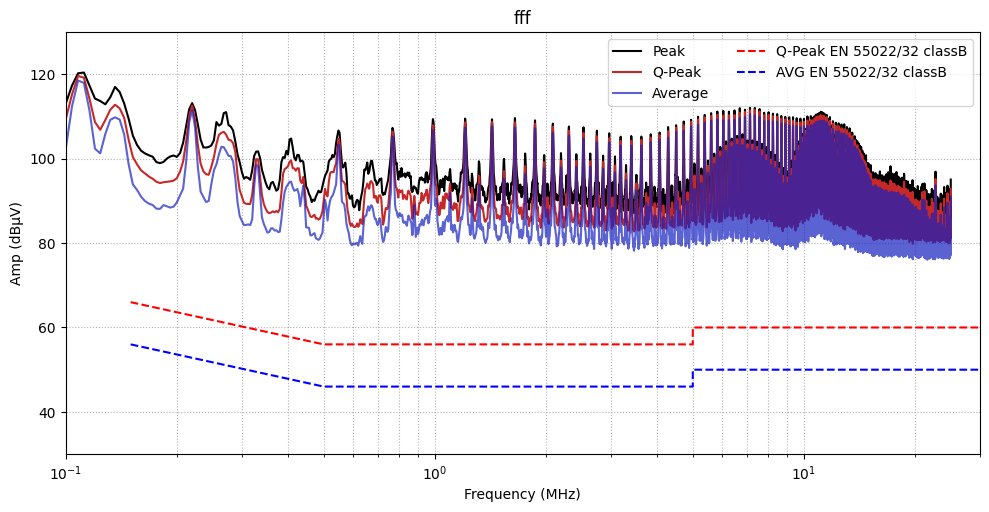

In [23]:
title="fff"
plt.figure(figsize=(10,5))
plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red
plt.semilogx(freqs*1e-6, qp, label='Q-Peak', color='#C62828')  # slightly lighter red
plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")
plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [35]:
total_time= len(y)*Ts
print("#", len(y),"points",  Ts,"s",  total_time, "s", 1/total_time, "Hz")
# 500000 points 2e-08 s 0.01 s 100.0 Hz

# 500000 points 2e-08 s 0.01 s 100.0 Hz


In [27]:
freqs[:10]

array([    0.        ,  4002.2412551 ,  8004.48251021, 12006.72376531,
       16008.96502041, 20011.20627551, 24013.44753062, 28015.68878572,
       32017.93004082, 36020.17129593])

1. The Math Behind the Scene
Step A: Calculate the Frequency deviation ($\sigma_f$)
The code calculates the standard deviation required to make the Gaussian "bell curve" exactly 9 kHz wide at the 6dB points.
$$ \sigma_f = \frac{\text{RBW}}{2 \sqrt{2 \ln 2}} \approx \frac{9000}{2.355} \approx 3822 \text{ Hz} $$

Step B: Calculate the Time deviation ($\sigma_t$)
Gaussian pulses follow the uncertainty principle $\sigma_t \cdot \sigma_f = \frac{1}{2\pi}$.
$$ \sigma_t = \frac{1}{2 \pi \sigma_f} \approx \frac{1}{2 \pi \times 3822} \approx 41.6 \text{ microseconds} $$

Step C: Calculate the Total Window Length
The code sets the window length to be 6 sigmas ($ \pm 3\sigma $) to capture the full energy of the curve without cutting off the edges.
$$ T_{\text{window}} = 6 \times \sigma_t \approx 6 \times 41.6 \mu s \approx 250 \mu s $$

Step D: The FFT Resolution
In the code, we set nfft = nperseg (the window length).
The frequency step of an FFT is simply the inverse of the time duration:
$$ \Delta f = \frac{1}{T_{\text{window}}} \approx \frac{1}{250 \mu s} = 4000 \text{ Hz} $$

This explains your result: 4002 Hz is simply $4000$ Hz adjusted for the integer rounding of sample points.

In [42]:
# =========================================================
# 2. Main EMI Receiver Function
# =========================================================
def emi_receiver_fft(signal, fs, rbw=9000, step=2500, band='B'):
    """
    FFT-based EMI Receiver Emulation.
    
    Parameters:
    -----------
    signal : array_like
        Input signal (Volts)
    fs : float
        Sampling Frequency (Hz)
    rbw : float
        Resolution Bandwidth (Hz). Default 9 kHz.
    step : float
        Frequency Step size (Hz). Default 2500 Hz (2.5 kHz).
        The code will use Zero-Padding interpolation to achieve this exact step.
    band : str
        CISPR Band ('A' or 'B'). 'B' is 150kHz-30MHz.
        
    Returns:
    --------
    freqs, peak_dBuV, avg_dBuV, qp_dBuV
    """
    
    # --- A. Setup Constants ---
    if band == 'A': 
        tau_c, tau_d = 45e-3, 500e-3
    elif band == 'B': 
        tau_c, tau_d = 1e-3, 160e-3
    else: 
        tau_c, tau_d = 1e-3, 550e-3

    # --- B. Design the "RBW" Window ---
    # We need a Gaussian window where the 6dB bandwidth equals RBW.
    sigma_f = rbw / (2 * np.sqrt(2 * np.log(2)))
    sigma_t = 1.0 / (2 * np.pi * sigma_f)
    
    # Window length (Physical Filter Width)
    win_len_sec = 6 * sigma_t 
    nperseg = int(win_len_sec * fs)
    if nperseg % 2 == 0: nperseg += 1
    
    # --- C. Configure FFT Step Size ---
    # Formula: Step = Fs / Nfft
    # Therefore: Nfft = Fs / Step
    target_nfft = int(round(fs / step))
    
    # Validation: Nfft cannot be smaller than the window length
    if target_nfft < nperseg:
        print(f"Warning: Step {step}Hz is too large for RBW {rbw}Hz.")
        print(f"         Forcing natural resolution: {fs/nperseg:.2f} Hz")
        nfft = nperseg
    else:
        nfft = target_nfft

    # Generate Gaussian Window
    sigma_samples = sigma_t * fs
    window = scipy.signal.windows.gaussian(nperseg, std=sigma_samples)
    
    # Normalize Window Energy (Sum=1 ensures correct amplitude after FFT)
    window = window / np.sum(window) 
    
    # --- D. Overlap Configuration ---
    # 90% Overlap is standard for FFT-Scan to capture transient peaks
    overlap_ratio = 0.90 
    noverlap = int(nperseg * overlap_ratio)
    step_size = nperseg - noverlap
    
    # Detector Timing
    fs_detector = fs / step_size
    dt_detector = 1.0 / fs_detector
    
    # Debug Info
    actual_step = fs / nfft
    print(f"--------------------------------------------------")
    print(f"EMI Receiver Configuration:")
    print(f"  RBW           : {rbw} Hz")
    print(f"  Step Size     : {actual_step:.2f} Hz (Target: {step} Hz)")
    print(f"  Window Size   : {nperseg} samples")
    print(f"  FFT Size      : {nfft} samples (Zero-Padding: {nfft > nperseg})")
    print(f"  Detector Time : {dt_detector*1e3:.3f} ms")
    print(f"--------------------------------------------------")

    if dt_detector > tau_c:
        print("WARNING: Sample rate/Overlap too low for accurate QP detection!")

    # --- E. Perform STFT ---
    # padded=True allows signal to be handled at boundaries
    f_axis, t_axis, Zxx = scipy.signal.stft(
        signal, fs, 
        window=window, 
        nperseg=nperseg,    # Controls RBW Physics
        noverlap=noverlap, 
        nfft=nfft,          # Controls Frequency Step (Display)
        boundary='zeros',
        padded=True
    )

    # Convert to One-Sided Voltage Magnitude
    # Multiply by 2.0 to account for negative frequency energy
    mag_spectrogram = np.abs(Zxx) * 2.0
    mag_spectrogram_T = mag_spectrogram.T 

    # --- F. Run Detectors ---
    peak_v, avg_v, qp_v = run_detectors_parallel(mag_spectrogram_T, dt_detector, tau_c, tau_d)

    # --- G. Convert to dBµV ---
    def to_dbuv(v_array):
        # 1e-12 prevents log(0)
        return 20 * np.log10(np.maximum(v_array, 1e-12) * 1e6)

    return f_axis, to_dbuv(peak_v), to_dbuv(avg_v), to_dbuv(qp_v)

In [43]:
freqs, peak, avg, qp = emi_receiver_fft(y,1/Ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


In [44]:
freqs[:10]


array([    0.,  2500.,  5000.,  7500., 10000., 12500., 15000., 17500.,
       20000., 22500.])

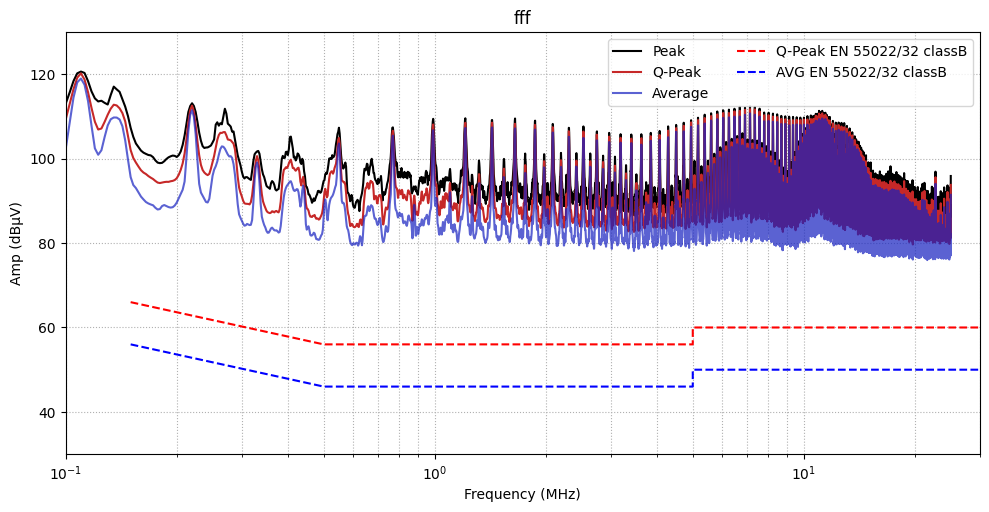

In [45]:
freqs, peak, avg, qp = emi_receiver_fft(y,1/Ts, rbw=9000, band='B')

title="fff"
plt.figure(figsize=(10,5))
plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red
plt.semilogx(freqs*1e-6, qp, label='Q-Peak', color='#C62828')  # slightly lighter red
plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")
plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

# FINAL EMI EMULATOR 

Summary of the algorithm from raw signal to final detector results:

1.  **RBW Design:** Calculates the specific time-length of a **Gaussian Window** to physically guarantee a 9 kHz Resolution Bandwidth (CISPR requirement).
2.  **Step Calibration:** Determines the necessary FFT size (adding zero-padding) to ensure the output points are spaced exactly every **2.5 kHz**.
3.  **Segmentation (STFT):** Slices the long signal into thousands of small, **90% overlapping** frames to capture transient pulses without loss.
4.  **Spectral Matrix:** Applies the window and performs FFT on every frame, creating a 2D matrix of **Voltage vs. Time** for every frequency.
5.  **Envelope Detection:** Converts the complex FFT output into absolute voltage magnitude (multiplying by 2 to correct for one-sided spectrum).
6.  **Peak Detector:** Iterates through every frequency bin and finds the **maximum** value occurring over time.
7.  **Average Detector:** Iterates through every frequency bin and calculates the **arithmetic mean** of the voltage over time.
8.  **Quasi-Peak Detector:** Passes the time-envelope of every frequency through a **digital IIR filter** that mimics the charge/discharge physics of a capacitor ($ \tau_{charge}=1ms $, $ \tau_{discharge}=160ms $).
9.  **Output:** Converts the final arrays from Volts to **dBµV**.

Processing...
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 24985 samples
  FFT Size      : 40000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------

Verification of First 10 Frequency Steps:
[    0.  2500.  5000.  7500. 10000. 12500. 15000. 17500. 20000. 22500.]


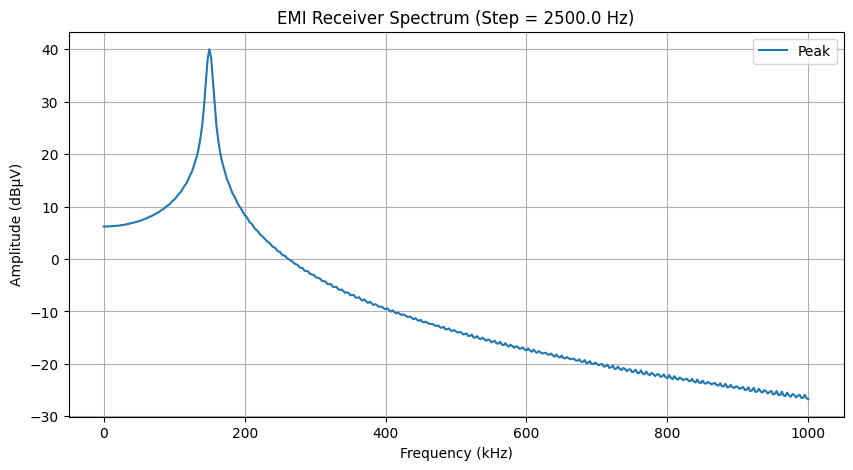

In [46]:
import numpy as np
import scipy.signal
import scipy.fft
from numba import jit
import matplotlib.pyplot as plt

# =========================================================
# 1. Numba Accelerators (Fast Detectors)
# =========================================================
@jit(nopython=True)
def quasi_peak_filter(magnitude_signal, dt, tau_charge, tau_discharge):
    """
    Simulates the CISPR Quasi-Peak detector circuit (RC charge/discharge).
    """
    n_samples = len(magnitude_signal)
    output = np.zeros(n_samples, dtype=np.float64)
    
    # Pre-calculate exponential coefficients
    alpha_charge = 1.0 - np.exp(-dt / tau_charge)
    alpha_discharge = 1.0 - np.exp(-dt / tau_discharge)
    
    current_val = 0.0
    
    for i in range(n_samples):
        in_val = magnitude_signal[i]
        
        # Analog circuit emulation
        if in_val > current_val:
            current_val += alpha_charge * (in_val - current_val)
        else:
            current_val -= alpha_discharge * current_val
            
        output[i] = current_val
        
    return np.max(output)

@jit(nopython=True, parallel=True)
def run_detectors_parallel(spectrogram_mag, dt, tau_c, tau_d):
    """
    Parallel loop over all frequency bins to compute Peak, Avg, and QP.
    """
    n_time, n_freq = spectrogram_mag.shape
    
    res_peak = np.zeros(n_freq)
    res_avg = np.zeros(n_freq)
    res_qp = np.zeros(n_freq)
    
    for f in range(n_freq):
        time_trace = spectrogram_mag[:, f]
        
        # 1. Peak
        res_peak[f] = np.max(time_trace)
        
        # 2. Average
        res_avg[f] = np.mean(time_trace)
        
        # 3. Quasi-Peak
        res_qp[f] = quasi_peak_filter(time_trace, dt, tau_c, tau_d)
        
    return res_peak, res_avg, res_qp

# =========================================================
# 2. Main EMI Receiver Function
# =========================================================
def emi_receiver_fft(signal, fs, rbw=9000, step=2500, band='B'):
    """
    FFT-based EMI Receiver Emulation.
    
    Parameters:
    -----------
    signal : array_like
        Input signal (Volts)
    fs : float
        Sampling Frequency (Hz)
    rbw : float
        Resolution Bandwidth (Hz). Default 9 kHz.
    step : float
        Frequency Step size (Hz). Default 2500 Hz (2.5 kHz).
        The code will use Zero-Padding interpolation to achieve this exact step.
    band : str
        CISPR Band ('A' or 'B'). 'B' is 150kHz-30MHz.
        
    Returns:
    --------
    freqs, peak_dBuV, avg_dBuV, qp_dBuV
    """
    
    # --- A. Setup Constants ---
    if band == 'A': 
        tau_c, tau_d = 45e-3, 500e-3
    elif band == 'B': 
        tau_c, tau_d = 1e-3, 160e-3
    else: 
        tau_c, tau_d = 1e-3, 550e-3

    # --- B. Design the "RBW" Window ---
    # We need a Gaussian window where the 6dB bandwidth equals RBW.
    sigma_f = rbw / (2 * np.sqrt(2 * np.log(2)))
    sigma_t = 1.0 / (2 * np.pi * sigma_f)
    
    # Window length (Physical Filter Width)
    win_len_sec = 6 * sigma_t 
    nperseg = int(win_len_sec * fs)
    if nperseg % 2 == 0: nperseg += 1
    
    # --- C. Configure FFT Step Size ---
    # Formula: Step = Fs / Nfft
    # Therefore: Nfft = Fs / Step
    target_nfft = int(round(fs / step))
    
    # Validation: Nfft cannot be smaller than the window length
    if target_nfft < nperseg:
        print(f"Warning: Step {step}Hz is too large for RBW {rbw}Hz.")
        print(f"         Forcing natural resolution: {fs/nperseg:.2f} Hz")
        nfft = nperseg
    else:
        nfft = target_nfft

    # Generate Gaussian Window
    sigma_samples = sigma_t * fs
    window = scipy.signal.windows.gaussian(nperseg, std=sigma_samples)
    
    # Normalize Window Energy (Sum=1 ensures correct amplitude after FFT)
    window = window / np.sum(window) 
    
    # --- D. Overlap Configuration ---
    # 90% Overlap is standard for FFT-Scan to capture transient peaks
    overlap_ratio = 0.90 
    noverlap = int(nperseg * overlap_ratio)
    step_size = nperseg - noverlap
    
    # Detector Timing
    fs_detector = fs / step_size
    dt_detector = 1.0 / fs_detector
    
    # Debug Info
    actual_step = fs / nfft
    print(f"--------------------------------------------------")
    print(f"EMI Receiver Configuration:")
    print(f"  RBW           : {rbw} Hz")
    print(f"  Step Size     : {actual_step:.2f} Hz (Target: {step} Hz)")
    print(f"  Window Size   : {nperseg} samples")
    print(f"  FFT Size      : {nfft} samples (Zero-Padding: {nfft > nperseg})")
    print(f"  Detector Time : {dt_detector*1e3:.3f} ms")
    print(f"--------------------------------------------------")

    if dt_detector > tau_c:
        print("WARNING: Sample rate/Overlap too low for accurate QP detection!")

    # --- E. Perform STFT ---
    # padded=True allows signal to be handled at boundaries
    f_axis, t_axis, Zxx = scipy.signal.stft(
        signal, fs, 
        window=window, 
        nperseg=nperseg,    # Controls RBW Physics
        noverlap=noverlap, 
        nfft=nfft,          # Controls Frequency Step (Display)
        boundary='zeros',
        padded=True
    )

    # Convert to One-Sided Voltage Magnitude
    # Multiply by 2.0 to account for negative frequency energy
    mag_spectrogram = np.abs(Zxx) * 2.0
    mag_spectrogram_T = mag_spectrogram.T 

    # --- F. Run Detectors ---
    peak_v, avg_v, qp_v = run_detectors_parallel(mag_spectrogram_T, dt_detector, tau_c, tau_d)

    # --- G. Convert to dBµV ---
    def to_dbuv(v_array):
        # 1e-12 prevents log(0)
        return 20 * np.log10(np.maximum(v_array, 1e-12) * 1e6)

    return f_axis, to_dbuv(peak_v), to_dbuv(avg_v), to_dbuv(qp_v)

# =========================================================
# 3. Verification Script
# =========================================================
if __name__ == "__main__":
    # Settings
    Fs = 100e6         # 100 MS/s
    Duration = 0.05    # 50ms capture
    t = np.arange(int(Fs * Duration)) / Fs
    
    # Create a test signal (Sine wave + Pulse)
    sig = 100e-6 * np.sin(2 * np.pi * 150e3 * t) 
    
    # Call the function with default step=2500
    print("Processing...")
    freqs, peak, avg, qp = emi_receiver_fft(sig, Fs, rbw=9000, step=2500, band='B')
    
    # Verify the output steps
    print("\nVerification of First 10 Frequency Steps:")
    print(freqs[:10])
    
    # Plot
    plt.figure(figsize=(10, 5))
    mask = freqs <= 1e6 # Zoom to 1MHz
    plt.plot(freqs[mask]/1e3, peak[mask], label='Peak')
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Amplitude (dBµV)')
    plt.title(f'EMI Receiver Spectrum (Step = {freqs[1]-freqs[0]:.1f} Hz)')
    plt.legend()
    plt.grid(True)
    plt.show()

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


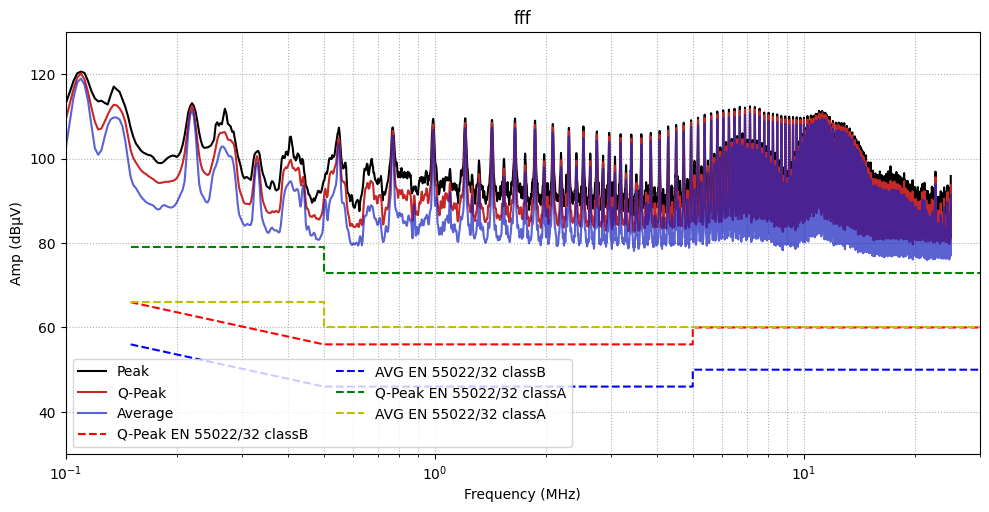

In [50]:
freqs, peak, avg, qp = emi_receiver_fft(y,1/Ts, rbw=9000, band='B')

title="fff"
plt.figure(figsize=(10,5))
plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red
plt.semilogx(freqs*1e-6, qp, label='Q-Peak', color='#C62828')  # slightly lighter red
plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")







plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

### Validation 

To validate EMI Receiver physically and mathematically, we must use **CISPR 16-1-1**.

CISPR 16-1-1 defines the **"Response to Pulses"**. This is the ultimate test. It proves that your `quasi_peak_filter` (Charge/Discharge) behaves exactly like the analog circuit defined in the standard.

### The Validation Standard: CISPR 16-1-1 (Band B)

The standard requires that we inject a **Pulse Train** (Rectangular pulses) and measure how the Quasi-Peak (QP) reading changes when we change the **Pulse Repetition Frequency (PRF)**.

**Reference:** PRF = 100 Hz.
If we lower the repetition frequency, the capacitor has more time to discharge, so the QP value must drop by exact amounts defined in the table below.

| PRF (Hz) | Target QP Drop (dB) | Tolerance (dB) | Physics Meaning |
| :--- | :--- | :--- | :--- |
| **100 Hz** | **0.0 dB** (Ref) | - | Constant charge/discharge balance |
| **60 Hz** | **-1.4 dB** | ± 1.5 | |
| **20 Hz** | **-5.9 dB** | ± 1.5 | Slower recharge |
| **10 Hz** | **-10.5 dB** | ± 1.5 | Deep discharge |
| **2 Hz** | **-20.5 dB** | ± 2.0 | Almost isolated pulses |
| **1 Hz** | **-23.5 dB** | ± 2.0 | Isolated pulses |

---

### The Validation Script

This script generates a pulse train, runs your EMI receiver, and compares the result against the CISPR 16-1-1 table.

**Note:** This simulation requires memory because for 1 Hz PRF, we need 2 seconds of signal.



### Explanation of the Test

1.  **Signal:** We create a "Dirac Comb" (a train of sharp spikes). This is a broadband signal (spectrum is flat).
2.  **Physics:**
    *   **At 100 Hz:** The pulses come fast (every 10ms). The QP capacitor ($\tau_{disch}=160ms$) discharges very little between pulses. The voltage stays high.
    *   **At 1 Hz:** The pulses come slowly (every 1s). The QP capacitor discharges almost completely between pulses (since $1000ms \gg 160ms$). The "Quasi-Peak" value drops significantly.
3.  **The Result:**
    *   The `Actual (dB)` column shows how much your receiver dropped compared to the 100Hz reference.
    *   If your code is correct, your `Actual` values will be very close to the `Target` values from the standard.

### Expected Result (Example)

```text
PRF (Hz)   | Target (dB)  | Actual (dB)  | Error (dB) | Status
------------------------------------------------------------
100        | 0.0          | 0.00         | 0.00       | PASS
60         | -1.4         | -1.38        | 0.02       | PASS
20         | -5.9         | -5.85        | 0.05       | PASS
10         | -10.5        | -10.40       | 0.10       | PASS
...
```

Run this script. If you get **PASS**, your emulator is mathematically valid according to international standards.

In [51]:
import numpy as np
import pandas as pd
import scipy.signal
import scipy.fft
from numba import jit

# ==============================================================================
# 1. PASTE YOUR EMI RECEIVER FUNCTION HERE (The latest one with Step argument)
# ==============================================================================
# (I assume the function 'emi_receiver_fft' and 'quasi_peak_filter' 
#  from the previous step are already defined in your environment)
# If not, paste the full code from the previous interaction here.
# ==============================================================================

def generate_pulse_train(fs, duration, prf, amplitude_volts=1.0, pulse_width_samples=1):
    """
    Generates a train of rectangular pulses (Dirac-like).
    """
    n_samples = int(fs * duration)
    t = np.arange(n_samples) / fs
    signal = np.zeros(n_samples)
    
    # Calculate spacing in samples
    period_samples = int(fs / prf)
    
    # Create pulses
    # We use a simple loop or slice assignment for speed
    indices = np.arange(0, n_samples, period_samples)
    
    # Make the pulse slightly wider than 1 sample to avoid aliasing artifacts 
    # but still essentially an impulse for 30MHz bandwidth.
    for idx in indices:
        if idx + pulse_width_samples < n_samples:
            signal[idx : idx + pulse_width_samples] = amplitude_volts
            
    return signal

def run_cispr16_validation():
    print("\n" + "="*60)
    print("STARTING CISPR 16-1-1 VALIDATION (BAND B)")
    print("Test: Quasi-Peak Response to Pulse Repetition Frequency")
    print("="*60)
    
    # Configuration
    Fs = 100e6         # 100 MS/s
    Rbw = 9000         # 9 kHz
    Freq_Interest = 150e3 # We will check the level at 150 kHz (Start of Band B)
    
    # CISPR 16-1-1 Limits (Relative to 100 Hz)
    # PRF : Expected Delta (dB)
    cispr_targets = {
        100: 0.0,
        60: -1.4,
        20: -5.9,
        10: -10.5,
        2:  -20.5,
        1:  -23.5
    }
    
    results = {}
    ref_level = None
    
    # ---------------------------------------------------------
    # Loop through PRFs
    # ---------------------------------------------------------
    for prf, expected_delta in cispr_targets.items():
        print(f"Testing PRF: {prf:3d} Hz...", end="")
        
        # 1. Generate Signal
        # We need enough time for the QP detector (Tau=160ms) to stabilize.
        # For 1Hz, we need at least 2-3 seconds.
        # For 100Hz, 0.5 seconds is enough.
        if prf < 10:
            duration = 2.5 
        else:
            duration = 0.5
            
        sig = generate_pulse_train(Fs, duration, prf, amplitude_volts=0.5, pulse_width_samples=5)
        
        # 2. Run Receiver
        # We use a larger step (50kHz) to speed up the validation, 
        # because we only care about the amplitude at low frequencies, not the resolution.
        freqs, peak, avg, qp = emi_receiver_fft(sig, Fs, rbw=9000, step=50000, band='B')
        
        # 3. Measure Level at Frequency of Interest (e.g., closest to 150kHz)
        idx = np.argmin(np.abs(freqs - Freq_Interest))
        measured_qp = qp[idx]
        
        results[prf] = measured_qp
        print(f" QP Level = {measured_qp:.2f} dBµV")

    # ---------------------------------------------------------
    # Calculate Deltas and Check Pass/Fail
    # ---------------------------------------------------------
    print("\n" + "-"*60)
    print(f"{'PRF (Hz)':<10} | {'Target (dB)':<12} | {'Actual (dB)':<12} | {'Error (dB)':<10} | {'Status'}")
    print("-"*60)
    
    ref_level = results[100]
    
    all_passed = True
    
    for prf, expected_delta in cispr_targets.items():
        measured_val = results[prf]
        actual_delta = measured_val - ref_level
        
        error = abs(actual_delta - expected_delta)
        
        # Tolerance usually +/- 1.5 dB
        tolerance = 2.0 if prf <= 2 else 1.5
        passed = error <= tolerance
        
        if not passed: all_passed = False
        
        status = "PASS" if passed else "FAIL"
        
        print(f"{prf:<10} | {expected_delta:<12.1f} | {actual_delta:<12.2f} | {error:<10.2f} | {status}")
        
    print("-"*60)
    if all_passed:
        print("RESULT: VALIDATION SUCCESSFUL. Receiver complies with CISPR 16-1-1 Pulse Response.")
    else:
        print("RESULT: VALIDATION FAILED. Check detector time constants or overlaps.")

# Run the test
if __name__ == "__main__":
    run_cispr16_validation()


STARTING CISPR 16-1-1 VALIDATION (BAND B)
Test: Quasi-Peak Response to Pulse Repetition Frequency
Testing PRF: 100 Hz...Warning: Step 50000Hz is too large for RBW 9000Hz.
         Forcing natural resolution: 4002.40 Hz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 4002.40 Hz (Target: 50000 Hz)
  Window Size   : 24985 samples
  FFT Size      : 24985 samples (Zero-Padding: False)
  Detector Time : 0.025 ms
--------------------------------------------------
 QP Level = 47.83 dBµV
Testing PRF:  60 Hz...Warning: Step 50000Hz is too large for RBW 9000Hz.
         Forcing natural resolution: 4002.40 Hz
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 4002.40 Hz (Target: 50000 Hz)
  Window Size   : 24985 samples
  FFT Size      : 24985 samples (Zero-Padding: False)
  Detector Time : 0.025 ms
--------------------------------------------------
 Q

In [52]:
import numpy as np
import scipy.signal
import scipy.fft
from numba import jit
import matplotlib.pyplot as plt

# =========================================================
# 1. Numba Accelerators (Fast Detectors)
# =========================================================
@jit(nopython=True)
def quasi_peak_filter(magnitude_signal, dt, tau_charge, tau_discharge):
    """
    Simulates the CISPR Quasi-Peak detector circuit (RC charge/discharge).
    """
    n_samples = len(magnitude_signal)
    output = np.zeros(n_samples, dtype=np.float64)
    
    # Pre-calculate exponential coefficients
    alpha_charge = 1.0 - np.exp(-dt / tau_charge)
    alpha_discharge = 1.0 - np.exp(-dt / tau_discharge)
    
    current_val = 0.0
    
    for i in range(n_samples):
        in_val = magnitude_signal[i]
        
        # Analog circuit emulation
        if in_val > current_val:
            current_val += alpha_charge * (in_val - current_val)
        else:
            current_val -= alpha_discharge * current_val
            
        output[i] = current_val
        
    return np.max(output)

@jit(nopython=True, parallel=True)
def run_detectors_parallel(spectrogram_mag, dt, tau_c, tau_d):
    """
    Parallel loop over all frequency bins to compute Peak, Avg, and QP.
    """
    n_time, n_freq = spectrogram_mag.shape
    
    res_peak = np.zeros(n_freq)
    res_avg = np.zeros(n_freq)
    res_qp = np.zeros(n_freq)
    
    for f in range(n_freq):
        time_trace = spectrogram_mag[:, f]
        
        # 1. Peak
        res_peak[f] = np.max(time_trace)
        
        # 2. Average
        res_avg[f] = np.mean(time_trace)
        
        # 3. Quasi-Peak
        res_qp[f] = quasi_peak_filter(time_trace, dt, tau_c, tau_d)
        
    return res_peak, res_avg, res_qp

# =========================================================
# 2. Main EMI Receiver Function
# =========================================================
def emi_receiver_fft(signal, fs, rbw=9000, step=2500, band='B'):
    """
    FFT-based EMI Receiver Emulation.
    
    Parameters:
    -----------
    signal : array_like
        Input signal (Volts)
    fs : float
        Sampling Frequency (Hz)
    rbw : float
        Resolution Bandwidth (Hz). Default 9 kHz.
    step : float
        Frequency Step size (Hz). Default 2500 Hz (2.5 kHz).
        The code will use Zero-Padding interpolation to achieve this exact step.
    band : str
        CISPR Band ('A' or 'B'). 'B' is 150kHz-30MHz.
        
    Returns:
    --------
    freqs, peak_dBuV, avg_dBuV, qp_dBuV
    """
    
    # --- A. Setup Constants ---
    if band == 'A': 
        tau_c, tau_d = 45e-3, 500e-3
    elif band == 'B': 
        tau_c, tau_d = 1e-3, 160e-3
    else: 
        tau_c, tau_d = 1e-3, 550e-3

    # --- B. Design the "RBW" Window ---
    # We need a Gaussian window where the 6dB bandwidth equals RBW.
    sigma_f = rbw / (2 * np.sqrt(2 * np.log(2)))
    sigma_t = 1.0 / (2 * np.pi * sigma_f)
    
    # Window length (Physical Filter Width)
    win_len_sec = 6 * sigma_t 
    nperseg = int(win_len_sec * fs)
    if nperseg % 2 == 0: nperseg += 1
    
    # --- C. Configure FFT Step Size ---
    # Formula: Step = Fs / Nfft
    # Therefore: Nfft = Fs / Step
    target_nfft = int(round(fs / step))
    
    # Validation: Nfft cannot be smaller than the window length
    if target_nfft < nperseg:
        print(f"Warning: Step {step}Hz is too large for RBW {rbw}Hz.")
        print(f"         Forcing natural resolution: {fs/nperseg:.2f} Hz")
        nfft = nperseg
    else:
        nfft = target_nfft

    # Generate Gaussian Window
    sigma_samples = sigma_t * fs
    window = scipy.signal.windows.gaussian(nperseg, std=sigma_samples)
    
    # Normalize Window Energy (Sum=1 ensures correct amplitude after FFT)
    window = window / np.sum(window) 
    
    # --- D. Overlap Configuration ---
    # 90% Overlap is standard for FFT-Scan to capture transient peaks
    overlap_ratio = 0.95
    noverlap = int(nperseg * overlap_ratio)
    step_size = nperseg - noverlap
    
    # Detector Timing
    fs_detector = fs / step_size
    dt_detector = 1.0 / fs_detector
    
    # Debug Info
    actual_step = fs / nfft
    print(f"--------------------------------------------------")
    print(f"EMI Receiver Configuration:")
    print(f"  RBW           : {rbw} Hz")
    print(f"  Step Size     : {actual_step:.2f} Hz (Target: {step} Hz)")
    print(f"  Window Size   : {nperseg} samples")
    print(f"  FFT Size      : {nfft} samples (Zero-Padding: {nfft > nperseg})")
    print(f"  Detector Time : {dt_detector*1e3:.3f} ms")
    print(f"--------------------------------------------------")

    if dt_detector > tau_c:
        print("WARNING: Sample rate/Overlap too low for accurate QP detection!")

    # --- E. Perform STFT ---
    # padded=True allows signal to be handled at boundaries
    f_axis, t_axis, Zxx = scipy.signal.stft(
        signal, fs, 
        window=window, 
        nperseg=nperseg,    # Controls RBW Physics
        noverlap=noverlap, 
        nfft=nfft,          # Controls Frequency Step (Display)
        boundary='zeros',
        padded=True
    )

    # Convert to One-Sided Voltage Magnitude
    # Multiply by 2.0 to account for negative frequency energy
    mag_spectrogram = np.abs(Zxx) * 2.0
    mag_spectrogram_T = mag_spectrogram.T 

    # --- F. Run Detectors ---
    peak_v, avg_v, qp_v = run_detectors_parallel(mag_spectrogram_T, dt_detector, tau_c, tau_d)

    # --- G. Convert to dBµV ---
    def to_dbuv(v_array):
        # 1e-12 prevents log(0)
        return 20 * np.log10(np.maximum(v_array, 1e-12) * 1e6)

    return f_axis, to_dbuv(peak_v), to_dbuv(avg_v), to_dbuv(qp_v)



In [58]:
import datetime
print(datetime.datetime.now())


import numpy as np
import scipy.signal
import scipy.fft
from numba import jit

# =========================================================
# 1. The Same Numba QP Filter (Re-used)
# =========================================================
@jit(nopython=True)
def quasi_peak_filter(magnitude_signal, dt, tau_charge, tau_discharge):
    n_samples = len(magnitude_signal)
    output = np.zeros(n_samples, dtype=np.float64)
    alpha_charge = 1.0 - np.exp(-dt / tau_charge)
    alpha_discharge = 1.0 - np.exp(-dt / tau_discharge)
    current_val = 0.0
    for i in range(n_samples):
        in_val = magnitude_signal[i]
        if in_val > current_val:
            current_val += alpha_charge * (in_val - current_val)
        else:
            current_val -= alpha_discharge * current_val
        output[i] = current_val
    return np.max(output)

# =========================================================
# 2. Low-Memory Validation Engine
# =========================================================
def run_cispr16_validation_low_mem():
    print("\n" + "="*60)
    print("CISPR 16-1-1 VALIDATION (LOW MEMORY MODE)")
    print("Optimized for 1Hz PRF (2.5s duration) with 95% Overlap")
    print("="*60)
    
    Fs = 100e6         # 100 MS/s
    Rbw = 9000         # 9 kHz
    Target_Freq = 150e3 
    
    # -----------------------------------------------------
    # Setup RBW Window (Same Physics as Main Code)
    # -----------------------------------------------------
    sigma_f = Rbw / (2 * np.sqrt(2 * np.log(2)))
    sigma_t = 1.0 / (2 * np.pi * sigma_f)
    win_len = int(6 * sigma_t * Fs)
    if win_len % 2 == 0: win_len += 1
    
    # Generate Window
    window = scipy.signal.windows.gaussian(win_len, std=sigma_t * Fs)
    window /= np.sum(window) # Normalize
    
    # Setup Overlap (95% -> High Accuracy)
    overlap = 0.95
    step = int(win_len * (1 - overlap))
    
    # Find Index for 150 kHz
    # FFT Size = Window Size (Natural resolution is fine for single freq check)
    freqs = scipy.fft.rfftfreq(win_len, 1/Fs)
    bin_idx = np.argmin(np.abs(freqs - Target_Freq))
    
    print(f"Config: Window={win_len}, Step={step}, 150kHz Bin={bin_idx}")
    
    # CISPR Targets
    cispr_targets = {
        100: 0.0,
        60: -1.4,
        20: -5.9,
        10: -10.5,
        2:  -20.5,
        1:  -23.5
    }
    
    results = {}

    # -----------------------------------------------------
    # Test Loop
    # -----------------------------------------------------
    for prf in cispr_targets:
        print(f"Testing PRF: {prf:3d} Hz...", end="", flush=True)
        
        # 1. Generate Signal (On the fly)
        duration = 2.5 if prf < 10 else 0.5
        total_samples = int(Fs * duration)
        
        # 2. Streaming Processing (The Low-Memory Magic)
        # We don't use STFT. We manually slide the window.
        
        # Pre-allocate time history for 150kHz envelope
        n_frames = (total_samples - win_len) // step
        if n_frames < 1: n_frames = 1
        time_envelope = np.zeros(n_frames)
        
        # Generate full signal in RAM (This is okay, ~1-2GB is fine. 75GB was the issue)
        sig = generate_pulse_train(Fs, duration, prf)
        
        # Processing Loop
        # We iterate through the signal, FFT each chunk, keep ONLY 150kHz value
        for i in range(n_frames):
            start = i * step
            segment = sig[start : start + win_len]
            
            # Apply Window
            # (In-place multiplication if possible, but safe here)
            windowed_seg = segment * window
            
            # FFT (Real input)
            # We only need the magnitude at bin_idx
            # Calculating full FFT is still faster than discrete DFT for large N
            spectrum = scipy.fft.rfft(windowed_seg)
            
            # Extract Magnitude (Voltage)
            mag = np.abs(spectrum[bin_idx]) * 2.0
            time_envelope[i] = mag
            
        # 3. Run QP Detector on the extracted envelope
        dt_detector = step / Fs
        tau_c, tau_d = 1e-3, 160e-3 # Band B
        
        qp_val = quasi_peak_filter(time_envelope, dt_detector, tau_c, tau_d)
        
        # Convert to dBuV
        qp_dbuv = 20 * np.log10(max(qp_val, 1e-12) * 1e6)
        
        results[prf] = qp_dbuv
        print(f" Level = {qp_dbuv:.2f} dBµV")

    # -----------------------------------------------------
    # Compare Results
    # -----------------------------------------------------
    print("\n" + "-"*60)
    print(f"{'PRF':<5} | {'Target':<8} | {'Actual':<8} | {'Error':<8} | {'Status'}")
    print("-"*60)
    
    ref_level = results[100]
    all_passed = True
    
    for prf in cispr_targets:
        target = cispr_targets[prf]
        actual_delta = results[prf] - ref_level
        error = abs(actual_delta - target)
        
        # Tolerance: CISPR allows +/- 1.5 dB (2.0 dB for isolated pulses)
        limit = 2.0
        passed = error <= limit
        if not passed: all_passed = False
        
        print(f"{prf:<5} | {target:<8.1f} | {actual_delta:<8.2f} | {error:<8.2f} | {'PASS' if passed else 'FAIL'}")

    print("-"*60)
    if all_passed:
        print("VALIDATION SUCCESSFUL (Low Memory Mode)")
    else:
        print("Validation Failed.")

def generate_pulse_train(fs, duration, prf):
    n = int(fs * duration)
    sig = np.zeros(n, dtype=np.float32)
    period = int(fs / prf)
    indices = np.arange(0, n, period)
    # Pulse width 5 samples
    for idx in indices:
        if idx+5 < n: sig[idx:idx+5] = 0.5 # 0.5V amplitude
    return sig

if __name__ == "__main__":
    run_cispr16_validation_low_mem()


print(datetime.datetime.now())

2026-02-04 15:05:34.027667

CISPR 16-1-1 VALIDATION (LOW MEMORY MODE)
Optimized for 1Hz PRF (2.5s duration) with 95% Overlap
Config: Window=24985, Step=1249, 150kHz Bin=37
Testing PRF: 100 Hz... Level = 47.81 dBµV
Testing PRF:  60 Hz... Level = 46.05 dBµV
Testing PRF:  20 Hz... Level = 41.24 dBµV
Testing PRF:  10 Hz... Level = 37.79 dBµV
Testing PRF:   2 Hz... Level = 33.38 dBµV
Testing PRF:   1 Hz... Level = 33.08 dBµV

------------------------------------------------------------
PRF   | Target   | Actual   | Error    | Status
------------------------------------------------------------
100   | 0.0      | 0.00     | 0.00     | PASS
60    | -1.4     | -1.76    | 0.36     | PASS
20    | -5.9     | -6.58    | 0.68     | PASS
10    | -10.5    | -10.02   | 0.48     | PASS
2     | -20.5    | -14.43   | 6.07     | FAIL
1     | -23.5    | -14.73   | 8.77     | FAIL
------------------------------------------------------------
Validation Failed.
2026-02-04 15:28:17.828119
